# Day 25 of ML 30-Days Challenge

# Task

**DBSCAN Clustering**: Explore a density-based clustering algorithm. Understand how DBSCAN can find arbitrarily shaped clusters and identify outliers as noise, without needing to specify the number of clusters beforehand.

In [16]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

###1. Data Preparation for DBSCAN

In [38]:
X, _ = make_moons(n_samples=2000, noise=0.08, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(2000, 2)

###2. Implementing the DBSCAN Model

In [39]:
dbscan = DBSCAN(eps=0.3, min_samples=10)
labels = dbscan.fit_predict(X_scaled)

###3. Analyzing Results

In [40]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

Number of clusters: 2
Number of noise points: 0


###4. Visualizing the DBSCAN Clusters with user-specified colors

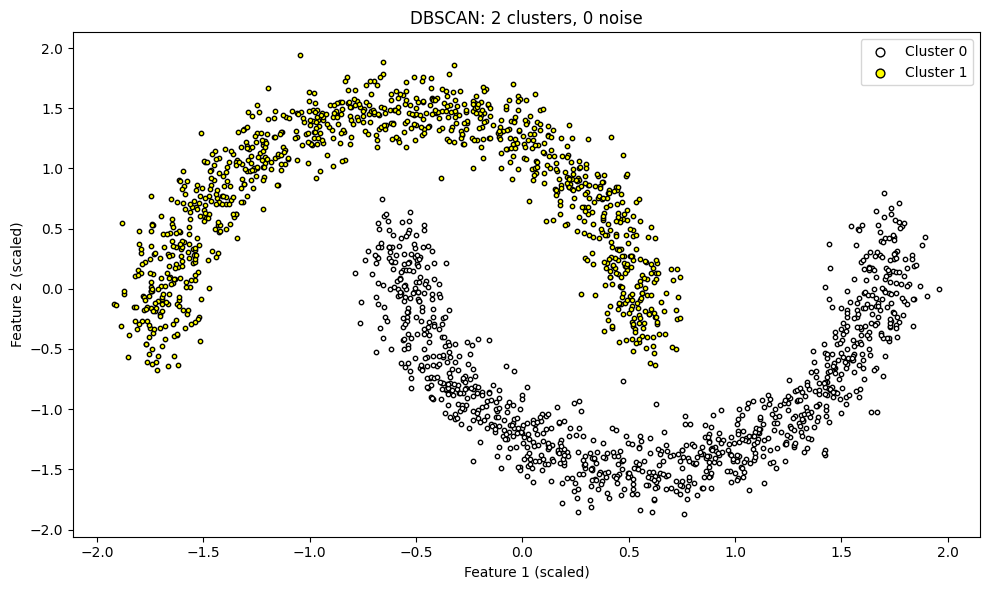

In [41]:
plt.figure(figsize=(10, 6))

cluster_colors = ['white', 'yellow']
for k in set(labels):
    class_mask = (labels == k)
    if k == -1:
        color = 'black'
        label_str = "Noise"
    else:
        color = cluster_colors[k % len(cluster_colors)]
        label_str = f"Cluster {k}"
    xy = X_scaled[class_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=color, s=10, edgecolor='k', label=label_str)

plt.title(f'DBSCAN: {n_clusters} clusters, {n_noise} noise')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()